In [54]:
"""
WSOD with Dedicated Spatial Attention Module + Multi-Scale Lightweight Transformer
Freezes backbone, trains only:
  - transformer blocks (trans1–4)
  - multi-scale fusion conv
  - spatial attention module
  - classifier FC
"""

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
import torchvision.transforms as transforms
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.metrics import roc_auc_score, precision_score, recall_score, f1_score
import timm
import cv2

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")

Using device: cuda


In [55]:
# ============================================================================
# Multi-Scale Lightweight Transformer Block
# ============================================================================

class TransformerBlock(nn.Module):
    """Ultra-lightweight Transformer block with spatial downsampling."""
    def __init__(self, dim, num_heads=2, mlp_ratio=1.0, dropout=0.1):
        super().__init__()
        self.norm1 = nn.LayerNorm(dim)
        self.attn = nn.MultiheadAttention(dim, num_heads, dropout=dropout, batch_first=True)
        self.norm2 = nn.LayerNorm(dim)

        mlp_hidden_dim = int(dim * mlp_ratio)
        self.mlp = nn.Sequential(
            nn.Linear(dim, mlp_hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_hidden_dim, dim),
            nn.Dropout(dropout)
        )

    def forward(self, x):
        B, C, H, W = x.shape

        # Downsample spatial dims for attention if too large (> 14×14)
        if H * W > 196:
            x_down = F.adaptive_avg_pool2d(x, (14, 14))
            _, _, H_d, W_d = x_down.shape
            x_seq = x_down.flatten(2).transpose(1, 2)
        else:
            x_seq = x.flatten(2).transpose(1, 2)
            H_d, W_d = H, W

        # Multi-head self-attention with residual
        x_norm = self.norm1(x_seq)
        attn_out, _ = self.attn(x_norm, x_norm, x_norm)
        x_seq = x_seq + attn_out

        # MLP with residual
        x_seq = x_seq + self.mlp(self.norm2(x_seq))

        # Reshape back
        x_out = x_seq.transpose(1, 2).reshape(B, C, H_d, W_d)

        # Upsample back if downsampled
        if H_d != H or W_d != W:
            x_out = F.interpolate(x_out, size=(H, W), mode='bilinear', align_corners=False)

        return x + x_out  # Residual from original input


In [56]:
# ============================================================================
# Spatial Attention Module
# ============================================================================

class SpatialAttentionModule(nn.Module):
    """
    Learnable spatial attention module.
    Takes fused multi-scale features and outputs spatial attention weights.
    """
    def __init__(self, in_channels=2048, reduction=8):
        super().__init__()
        mid = in_channels // reduction

        self.conv1    = nn.Conv2d(in_channels, mid, kernel_size=1)
        self.bn1      = nn.BatchNorm2d(mid)
        self.conv2    = nn.Conv2d(mid, mid, kernel_size=3, padding=1)
        self.bn2      = nn.BatchNorm2d(mid)
        self.conv_out = nn.Conv2d(mid, 1, kernel_size=1)
        self.relu     = nn.ReLU(inplace=True)
        self.sigmoid  = nn.Sigmoid()

    def forward(self, x):
        """
        Args:
            x: [B, 2048, 7, 7] fused features
        Returns:
            attention: [B, 1, 7, 7]
            weighted_features: [B, 2048, 7, 7]
        """
        att = self.relu(self.bn1(self.conv1(x)))
        att = self.relu(self.bn2(self.conv2(att)))
        attention = self.sigmoid(self.conv_out(att))
        return attention, x * attention

In [57]:
# ============================================================================
# WSOD Model: Multi-Scale Transformer + Spatial Attention
# ============================================================================

class WSODModelWithAttention(nn.Module):
    """
    ResNet-50 backbone (frozen) with:
      - lightweight TransformerBlock after each of the 4 stages
      - multi-scale feature fusion
      - SpatialAttentionModule on fused features
      - linear classifier
    """
    def __init__(self, base_model, num_classes=2, freeze_backbone=True,
                 num_heads=2, dropout=0.1):
        super().__init__()

        # ── Backbone stages ──────────────────────────────────────────────────
        children = list(base_model.children())
        # Standard torchvision ResNet layout:
        #   [0] conv1  [1] bn1  [2] relu  [3] maxpool
        #   [4] layer1 [5] layer2 [6] layer3 [7] layer4
        #   [8] avgpool [9] fc
        self.stem   = nn.Sequential(*children[:4])   # → H/4,  64 ch (after maxpool: 256 if using timm)
        self.stage1 = children[4]   # → H/4,  256 ch
        self.stage2 = children[5]   # → H/8,  512 ch
        self.stage3 = children[6]   # → H/16, 1024 ch
        self.stage4 = children[7]   # → H/32, 2048 ch

        if freeze_backbone:
            for module in [self.stem, self.stage1, self.stage2, self.stage3, self.stage4]:
                for p in module.parameters():
                    p.requires_grad = False
            print("✓ Backbone frozen")

        # ── Transformer blocks (TRAINABLE) ───────────────────────────────────
        self.trans1 = TransformerBlock(256,  num_heads=2,        mlp_ratio=1.0, dropout=dropout)
        self.trans2 = TransformerBlock(512,  num_heads=2,        mlp_ratio=1.0, dropout=dropout)
        self.trans3 = TransformerBlock(1024, num_heads=num_heads, mlp_ratio=1.0, dropout=dropout)
        self.trans4 = TransformerBlock(2048, num_heads=num_heads, mlp_ratio=1.0, dropout=dropout)

        # ── Multi-scale fusion (TRAINABLE) ───────────────────────────────────
        # Project each scale to 512-d, then cat → 2048-d
        PROJ = 512
        self.proj1 = nn.Sequential(nn.Conv2d(256,  PROJ, 1), nn.BatchNorm2d(PROJ), nn.ReLU(inplace=True))
        self.proj2 = nn.Sequential(nn.Conv2d(512,  PROJ, 1), nn.BatchNorm2d(PROJ), nn.ReLU(inplace=True))
        self.proj3 = nn.Sequential(nn.Conv2d(1024, PROJ, 1), nn.BatchNorm2d(PROJ), nn.ReLU(inplace=True))
        self.proj4 = nn.Sequential(nn.Conv2d(2048, PROJ, 1), nn.BatchNorm2d(PROJ), nn.ReLU(inplace=True))
        # Compress 4×512 = 2048 → 2048 (could also be a plain identity if desired)
        self.fusion = nn.Sequential(
            nn.Conv2d(PROJ * 4, 2048, 1),
            nn.BatchNorm2d(2048),
            nn.ReLU(inplace=True)
        )

        # ── Spatial attention (TRAINABLE) ────────────────────────────────────
        self.spatial_attention = SpatialAttentionModule(in_channels=2048)

        # ── Classifier (TRAINABLE) ───────────────────────────────────────────
        self.avgpool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Linear(2048, num_classes)

        # Optionally copy FC weights from base model
        if freeze_backbone:
            orig_fc = children[-1]
            if isinstance(orig_fc, nn.Linear) and orig_fc.out_features == num_classes:
                self.fc.weight.data.copy_(orig_fc.weight.data)
                self.fc.bias.data.copy_(orig_fc.bias.data)

    # -------------------------------------------------------------------------
    def _extract_multiscale(self, x):
        """Run through backbone + transformers, return features at all 4 scales."""
        x = self.stem(x)

        s1 = self.stage1(x);  s1 = self.trans1(s1)   # [B, 256,  H/4,  W/4 ]
        s2 = self.stage2(s1); s2 = self.trans2(s2)   # [B, 512,  H/8,  W/8 ]
        s3 = self.stage3(s2); s3 = self.trans3(s3)   # [B, 1024, H/16, W/16]
        s4 = self.stage4(s3); s4 = self.trans4(s4)   # [B, 2048, H/32, W/32]
        return s1, s2, s3, s4

    def _fuse(self, s1, s2, s3, s4):
        """Project all scales to target resolution (7×7) and fuse."""
        target = s4.shape[2:]   # (7, 7) for 224-px input

        f1 = F.adaptive_avg_pool2d(self.proj1(s1), target)
        f2 = F.adaptive_avg_pool2d(self.proj2(s2), target)
        f3 = F.adaptive_avg_pool2d(self.proj3(s3), target)
        f4 = self.proj4(s4)

        fused = torch.cat([f1, f2, f3, f4], dim=1)  # [B, 2048, 7, 7]
        return self.fusion(fused)                    # [B, 2048, 7, 7]

    # -------------------------------------------------------------------------
    def forward(self, x, return_attention=False):
        s1, s2, s3, s4 = self._extract_multiscale(x)
        fused = self._fuse(s1, s2, s3, s4)

        attention_map, weighted = self.spatial_attention(fused)

        pooled = self.avgpool(weighted).flatten(1)
        output = self.fc(pooled)

        if return_attention:
            return output, attention_map
        return output

    def get_attention_map(self, x):
        """Return spatial attention map for visualization (no grad)."""
        with torch.no_grad():
            s1, s2, s3, s4 = self._extract_multiscale(x)
            fused = self._fuse(s1, s2, s3, s4)
            attention_map, _ = self.spatial_attention(fused)
        return attention_map

In [58]:
# ============================================================================
# Attention-based Loss Functions  (unchanged)
# ============================================================================

def bbox_to_gaussian_mask(bbox, target_size=(7, 7), sigma_scale=1.0):
    batch_size = bbox.shape[0]
    h, w = target_size
    y_coords = torch.linspace(0, 1, h, device=bbox.device).view(-1, 1).expand(h, w)
    x_coords = torch.linspace(0, 1, w, device=bbox.device).view(1, -1).expand(h, w)

    masks = []
    for i in range(batch_size):
        bx, by, bw, bh = bbox[i]
        cx, cy = bx + bw / 2, by + bh / 2
        sx = max((bw / 2) * sigma_scale, 0.05)
        sy = max((bh / 2) * sigma_scale, 0.05)
        gaussian = torch.exp(
            -((x_coords - cx) ** 2) / (2 * sx ** 2) -
            ((y_coords - cy) ** 2) / (2 * sy ** 2)
        )
        masks.append(gaussian)
    return torch.stack(masks).unsqueeze(1)


def spatial_attention_loss(attention_map, bbox, label, sigma_scale=1.0):
    positive_mask = label == 1
    if positive_mask.sum() == 0:
        return torch.tensor(0.0, device=attention_map.device)

    pos_attention = attention_map[positive_mask]
    pos_bbox      = bbox[positive_mask]
    target_size   = (pos_attention.shape[2], pos_attention.shape[3])
    gaussian_masks = bbox_to_gaussian_mask(pos_bbox, target_size, sigma_scale)

    mse_loss = F.mse_loss(pos_attention, gaussian_masks)

    att_prob  = pos_attention / (pos_attention.sum(dim=(2,3), keepdim=True) + 1e-8)
    tgt_prob  = gaussian_masks / (gaussian_masks.sum(dim=(2,3), keepdim=True) + 1e-8)
    kl_loss   = F.kl_div((att_prob + 1e-8).log(), tgt_prob, reduction='batchmean')

    return 0.5 * mse_loss + 0.5 * kl_loss

# ============================================================================
# STAGE 2 TRAINING FUNCTIONS
# ============================================================================

def train_epoch_attention_only(model, loader, optimizer, device, sigma_scale=1.0):
    model.train()

    # Force everything except spatial attention into eval mode
    for name, module in model.named_children():
        if name != 'spatial_attention':
            module.eval()
    model.spatial_attention.train()

    running_att_loss = 0.0
    all_preds, all_labels = [], []

    pbar = tqdm(loader, desc='Training Attention Only')
    for images, labels, bboxes in pbar:
        images, labels, bboxes = images.to(device), labels.to(device), bboxes.to(device)
        optimizer.zero_grad()

        # Frozen backbone — no grad needed
        with torch.no_grad():
            s1, s2, s3, s4 = model._extract_multiscale(images)
            fused = model._fuse(s1, s2, s3, s4)

        # Enable grad only for attention
        fused = fused.detach().requires_grad_(True)
        attention_map, weighted = model.spatial_attention(fused)

        # Attention loss ONLY — no classification loss
        loss = spatial_attention_loss(attention_map, bboxes, labels, sigma_scale)

        if loss.requires_grad:
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.spatial_attention.parameters(), 1.0)
            optimizer.step()

        running_att_loss += loss.item()

        # Monitor classification (frozen — just for tracking)
        with torch.no_grad():
            pooled = model.avgpool(weighted.detach()).flatten(1)
            output = model.fc(pooled)
            _, predicted = output.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

        pbar.set_postfix({'att_loss': running_att_loss / (pbar.n + 1)})

    acc = 100. * sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    return running_att_loss / len(loader), acc


def validate_attention(model, loader, device, lambda_att=1.0):
    model.eval()
    running_att_loss = 0.0
    all_preds, all_labels = [], []
    all_ious = []

    with torch.no_grad():
        for images, labels, bboxes in tqdm(loader, desc='Validation'):
            images, labels, bboxes = images.to(device), labels.to(device), bboxes.to(device)

            logits, attention_map = model(images, return_attention=True)

            # Attention loss
            loss = spatial_attention_loss(attention_map, bboxes, labels, lambda_att)
            running_att_loss += loss.item()

            # Classification (frozen, just monitoring)
            _, predicted = logits.max(1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

            # Attention IoU for positive samples
            for i in range(images.size(0)):
                if labels[i] == 0:
                    continue
                bbox = bboxes[i].cpu().numpy()
                if bbox[0] == 0 and bbox[1] == 0 and bbox[2] == 0 and bbox[3] == 0:
                    continue
                att_map = attention_map[i, 0].cpu().numpy()
                iou = calculate_attention_iou(att_map, bbox, threshold=0.5)
                all_ious.append(iou)

    acc      = 100. * sum(p == l for p, l in zip(all_preds, all_labels)) / len(all_labels)
    mean_iou = np.mean(all_ious) if all_ious else 0.0
    return running_att_loss / len(loader), acc, mean_iou


def calculate_attention_iou(attention_map, bbox, threshold=0.5):
    H, W = attention_map.shape

    # Binarize attention map
    attention_binary = (attention_map > threshold).astype(np.float32)

    # Create bbox mask
    x, y, w, h = bbox
    x1 = max(0, int(x * W))
    y1 = max(0, int(y * H))
    x2 = min(W, int((x + w) * W))
    y2 = min(H, int((y + h) * H))

    bbox_mask = np.zeros((H, W), dtype=np.float32)
    bbox_mask[y1:y2, x1:x2] = 1.0

    intersection = np.sum(attention_binary * bbox_mask)
    union        = np.sum((attention_binary + bbox_mask) > 0)

    return intersection / union if union > 0 else 0.0

In [59]:
# ============================================================================
# Training / Validation  (unchanged signatures)
# ============================================================================

def train_epoch_wsod(model, loader, criterion, optimizer, device,
                     attention_weight=0.5, sigma_scale=1.0):
    model.train()
    running_loss = running_cls = running_att = correct = total = 0
    all_preds, all_labels, all_probs = [], [], []

    pbar = tqdm(loader, desc='Training WSOD')
    for images, labels, bboxes in pbar:
        images, labels, bboxes = images.to(device), labels.to(device), bboxes.to(device)
        optimizer.zero_grad()

        outputs, attention_map = model(images, return_attention=True)
        cls_loss = criterion(outputs, labels)
        att_loss = spatial_attention_loss(attention_map, bboxes, labels, sigma_scale)
        loss     = cls_loss + attention_weight * att_loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        running_loss += loss.item()
        running_cls  += cls_loss.item()
        running_att  += att_loss.item()

        probs = torch.softmax(outputs, dim=1)
        _, predicted = outputs.max(1)
        total   += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())
        all_probs.extend(probs[:, 1].cpu().detach().numpy())

        pbar.set_postfix({
            'loss': running_loss / len(pbar),
            'cls':  running_cls  / len(pbar),
            'att':  running_att  / len(pbar),
            'acc':  f'{100.*correct/total:.1f}%'
        })

    n = len(loader)
    return (running_loss/n, running_cls/n, running_att/n,
            100.*correct/total, all_preds, all_labels, all_probs)


def validate_wsod(model, loader, criterion, device):
    model.eval()
    running_loss = correct = total = 0
    all_preds, all_labels, all_probs = [], [], []

    with torch.no_grad():
        for images, labels, bboxes in tqdm(loader, desc='Validation'):
            images, labels = images.to(device), labels.to(device)
            outputs  = model(images)
            loss     = criterion(outputs, labels)
            running_loss += loss.item()

            probs = torch.softmax(outputs, dim=1)
            _, predicted = outputs.max(1)
            total   += labels.size(0)
            correct += predicted.eq(labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
            all_probs.extend(probs[:, 1].cpu().numpy())

    n = len(loader)
    prec   = precision_score(all_labels, all_preds, average='binary', zero_division=0)
    recall = recall_score   (all_labels, all_preds, average='binary', zero_division=0)
    f1     = f1_score       (all_labels, all_preds, average='binary', zero_division=0)
    auc    = roc_auc_score  (all_labels, all_probs)

    return (running_loss/n, 100.*correct/total,
            all_preds, all_labels, all_probs,
            prec, recall, f1, auc)

In [60]:
# ============================================================================
# Visualization  (unchanged)
# ============================================================================

def visualize_attention_with_bbox(model, image, bboxes, label, pred,
                                  img_name=None, denormalize=True):
    model.eval()
    if denormalize:
        mean = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1)
        std  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1)
        image_display = (image.cpu() * std + mean).clamp(0, 1)
    else:
        image_display = image.cpu()

    with torch.no_grad():
        attention_map = model.get_attention_map(image.unsqueeze(0).to(device))
        attention_map = attention_map.squeeze().cpu().numpy()

    attention_resized = cv2.resize(attention_map, (224, 224))
    img_np = image_display.permute(1,2,0).numpy()

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    title0 = (f'Original: {img_name}\n' if img_name else 'Original\n') + f'GT:{label}, Pred:{pred}'
    for ax, t in zip(axes, [title0, 'Spatial Attention', 'Attention + GT BBox']):
        ax.imshow(img_np); ax.set_title(t, fontsize=12, fontweight='bold'); ax.axis('off')

    im = axes[1].imshow(attention_resized, cmap='jet', alpha=0.5)
    plt.colorbar(im, ax=axes[1], fraction=0.046)

    axes[2].imshow(attention_resized, cmap='jet', alpha=0.5)
    if label == 1:
        if not isinstance(bboxes, list):
            bboxes = [bboxes]
        for bbox in bboxes:
            x, y, w, h = bbox.cpu().numpy()
            rect = plt.Rectangle((x*224, y*224), w*224, h*224,
                                  fill=False, edgecolor='lime', linewidth=2)
            axes[2].add_patch(rect)
        axes[2].legend([f'GT BBox ({len(bboxes)} nodule{"s" if len(bboxes)>1 else ""})'], fontsize=10)

    plt.tight_layout()
    return fig


print("=" * 80)
print("Setup complete — WSOD + Multi-Scale Transformer Attention!")
print("=" * 80)

Setup complete — WSOD + Multi-Scale Transformer Attention!


In [61]:
# ============================================================================
# CONFIGURATION
# ============================================================================

BATCH_SIZE = 16
NUM_EPOCHS = 30  # More epochs since attention module learns from scratch
LEARNING_RATE = 3e-4  # Higher LR for attention module (backbone is frozen)
IMAGE_SIZE = 224
NUM_WORKERS = 4
WEIGHT_DECAY = 0.01
ATTENTION_WEIGHT = 0.1  # Can be higher since backbone is safe
SIGMA_SCALE = 1.0  # Start strict, can adjust if needed

# Paths
split_base_path = "./dataset_nodule21/cxr_images/proccessed_data/split_data"
checkpoint_path = "./resnet50_binary.pth"

train_images_path = f"{split_base_path}/train/images"
val_images_path = f"{split_base_path}/val/images"
test_images_path = f"{split_base_path}/test/images"

train_csv_path = f"{split_base_path}/train/metadata_no_aug.csv"
val_csv_path = f"{split_base_path}/val/metadata_val.csv"
test_csv_path = f"{split_base_path}/test/metadata_test.csv"

In [62]:
# ============================================================================
# LOAD DATA
# ============================================================================

print("\nLoading datasets...")
train_df = pd.read_csv(train_csv_path)
val_df = pd.read_csv(val_csv_path)
test_df = pd.read_csv(test_csv_path)

print(f"Train samples: {len(train_df)}")
print(f"Val samples: {len(val_df)}")
print(f"Test samples: {len(test_df)}")

# Transforms
train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ColorJitter(brightness=0.15, contrast=0.15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

val_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Create datasets with bbox
from NoduleDS import NoduleDataset

train_dataset = NoduleDataset(train_df, train_images_path, transform=train_transform, return_bbox=True)
val_dataset = NoduleDataset(val_df, val_images_path, transform=val_transform, return_bbox=True)
test_dataset = NoduleDataset(test_df, test_images_path, transform=val_transform, return_bbox=True)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)



Loading datasets...
Train samples: 3657
Val samples: 782
Test samples: 785


In [63]:
# ============================================================================
# BUILD MODEL — STAGE 2 (Attention-Only Fine-tuning)
# ============================================================================

base_model = timm.create_model('resnet50', pretrained=False, num_classes=2)

# Load your binary classifier as Stage 1
ckpt = torch.load('./resnet50_binary.pth', map_location='cpu')
state = ckpt['model_state_dict'] if 'model_state_dict' in ckpt else ckpt
base_model.load_state_dict(state, strict=False)

model = WSODModelWithAttention(
    base_model,
    num_classes=2,
    freeze_backbone=False,  # handled manually below
    num_heads=2,
    dropout=0.1
).to(device)

# Freeze EVERYTHING including FC
for param in model.parameters():
    param.requires_grad = False

# Unfreeze only spatial attention
for param in model.spatial_attention.parameters():
    param.requires_grad = True

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())
print(f"Trainable: {trainable:,} / {total:,} ({100*trainable/total:.1f}%)")
print("Only SpatialAttentionModule is trainable — classification frozen")

criterion = nn.CrossEntropyLoss()  # validation monitoring only
optimizer = optim.AdamW(model.spatial_attention.parameters(), lr=1e-4, weight_decay=0.01)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS)

Trainable: 1,115,905 / 64,262,467 (1.7%)
Only SpatialAttentionModule is trainable — classification frozen


In [64]:
# ============================================================================
# TRAINING LOOP — STAGE 2 (Attention Only)
# ============================================================================

print("\n" + "=" * 80)
print("Starting Stage 2 — Attention-Only Fine-tuning")
print("=" * 80)

history = {
    'train_att_loss': [], 'train_acc': [],
    'val_att_loss': [],   'val_acc': [], 'val_iou': []
}

best_val_iou = 0.0
best_model_path = 'best_wsod_resvit.pth'

for epoch in range(NUM_EPOCHS):
    print(f"\nEpoch {epoch+1}/{NUM_EPOCHS}")
    print("-" * 80)

    # Train — attention only
    train_att_loss, train_acc = train_epoch_attention_only(
        model, train_loader, optimizer, device, sigma_scale=1.0
    )

    # Validate
    val_att_loss, val_acc, val_iou = validate_attention(
        model, val_loader, device, lambda_att=1.0
    )

    scheduler.step()

    # Save history
    history['train_att_loss'].append(train_att_loss)
    history['train_acc'].append(train_acc)
    history['val_att_loss'].append(val_att_loss)
    history['val_acc'].append(val_acc)
    history['val_iou'].append(val_iou)

    print(f"\nTrain - Att Loss: {train_att_loss:.4f}, Acc: {train_acc:.2f}% (frozen)")
    print(f"Val   - Att Loss: {val_att_loss:.4f}, Acc: {val_acc:.2f}% (frozen)")
    print(f"Val   - IoU: {val_iou:.4f} ← MAIN METRIC")
    print(f"LR: {optimizer.param_groups[0]['lr']:.6f}")

    # Save best model based on IoU (not F1 — classifier is frozen)
    if val_iou > best_val_iou:
        best_val_iou = val_iou
        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_acc': val_acc,
            'val_iou': val_iou,
        }, best_model_path)
        print(f"✓ Saved best model (IoU: {val_iou:.4f})")

print("\n" + "=" * 80)
print("Training completed!")
print(f"Best validation IoU: {best_val_iou:.4f}")
print("=" * 80)


Starting Stage 2 — Attention-Only Fine-tuning

Epoch 1/30
--------------------------------------------------------------------------------


Validation: 100%|██████████| 49/49 [00:11<00:00,  4.15it/s]



Train - Att Loss: 1.2739, Acc: 28.47% (frozen)
Val   - Att Loss: 0.3591, Acc: 28.90% (frozen)
Val   - IoU: 0.0116 ← MAIN METRIC
LR: 0.000100
✓ Saved best model (IoU: 0.0116)

Epoch 2/30
--------------------------------------------------------------------------------


Validation: 100%|██████████| 49/49 [00:15<00:00,  3.11it/s]



Train - Att Loss: 1.1486, Acc: 28.47% (frozen)
Val   - Att Loss: 0.3421, Acc: 28.90% (frozen)
Val   - IoU: 0.0154 ← MAIN METRIC
LR: 0.000099
✓ Saved best model (IoU: 0.0154)

Epoch 3/30
--------------------------------------------------------------------------------


...


Train - Att Loss: 0.8698, Acc: 28.33% (frozen)
Val   - Att Loss: 0.3227, Acc: 28.77% (frozen)
Val   - IoU: 0.0111 ← MAIN METRIC
LR: 0.000087

Epoch 8/30
--------------------------------------------------------------------------------


Validation: 100%|██████████| 49/49 [00:14<00:00,  3.42it/s]



Train - Att Loss: 0.7939, Acc: 28.27% (frozen)
Val   - Att Loss: 0.3392, Acc: 28.77% (frozen)
Val   - IoU: 0.0120 ← MAIN METRIC
LR: 0.000083

Epoch 9/30
--------------------------------------------------------------------------------


Training Attention Only:  52%|█████▏    | 119/229 [00:30<00:28,  3.86it/s, att_loss=0.748]


KeyboardInterrupt: 

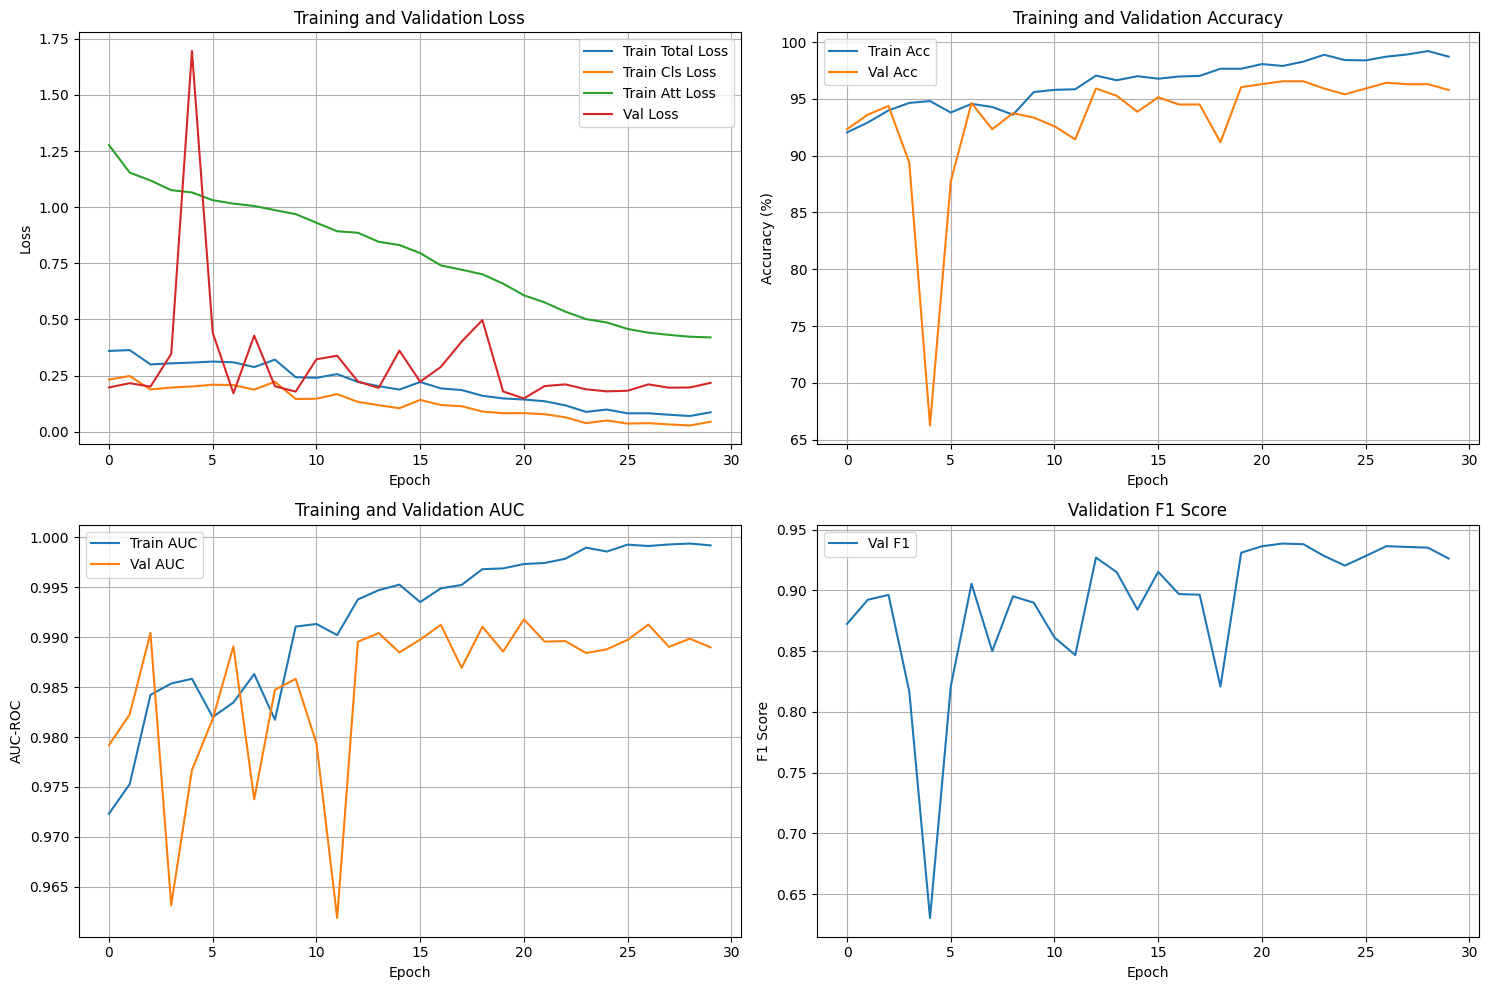

Training curves saved to 'wsod_training_history.png'


In [ ]:
# ============================================================================
# PLOT TRAINING HISTORY
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Loss
axes[0, 0].plot(history['train_loss'], label='Train Total Loss')
axes[0, 0].plot(history['train_cls_loss'], label='Train Cls Loss')
axes[0, 0].plot(history['train_att_loss'], label='Train Att Loss')
axes[0, 0].plot(history['val_loss'], label='Val Loss')
axes[0, 0].set_xlabel('Epoch')
axes[0, 0].set_ylabel('Loss')
axes[0, 0].set_title('Training and Validation Loss')
axes[0, 0].legend()
axes[0, 0].grid(True)

# Accuracy
axes[0, 1].plot(history['train_acc'], label='Train Acc')
axes[0, 1].plot(history['val_acc'], label='Val Acc')
axes[0, 1].set_xlabel('Epoch')
axes[0, 1].set_ylabel('Accuracy (%)')
axes[0, 1].set_title('Training and Validation Accuracy')
axes[0, 1].legend()
axes[0, 1].grid(True)

# AUC
axes[1, 0].plot(history['train_auc'], label='Train AUC')
axes[1, 0].plot(history['val_auc'], label='Val AUC')
axes[1, 0].set_xlabel('Epoch')
axes[1, 0].set_ylabel('AUC-ROC')
axes[1, 0].set_title('Training and Validation AUC')
axes[1, 0].legend()
axes[1, 0].grid(True)

# F1 Score
axes[1, 1].plot(history['val_f1'], label='Val F1')
axes[1, 1].set_xlabel('Epoch')
axes[1, 1].set_ylabel('F1 Score')
axes[1, 1].set_title('Validation F1 Score')
axes[1, 1].legend()
axes[1, 1].grid(True)

plt.tight_layout()
plt.savefig('wsod_training_history.png', dpi=150, bbox_inches='tight')
plt.show()

print("Training curves saved to 'wsod_training_history.png'")

In [ ]:
# ============================================================================
# LOAD BEST MODEL FOR TESTING
# ============================================================================

print("\n" + "=" * 80)
print("Loading best model for testing...")
print("=" * 80)

checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"Loaded best model from epoch {checkpoint['epoch']+1}")
print(f"Best val F1: {checkpoint['val_f1']:.4f}")


Loading best model for testing...
Loaded best model from epoch 22
Best val F1: 0.9385


In [ ]:
# ============================================================================
# TEST SET EVALUATION
# ============================================================================

print("\nEvaluating on test set...")

test_loss, test_acc, test_preds, test_labels, test_probs, test_prec, test_recall, test_f1, test_auc = validate_wsod(
    model, test_loader, criterion, device
)

print("\n" + "=" * 80)
print("TEST SET RESULTS")
print("=" * 80)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_acc:.2f}%")
print(f"Test AUC-ROC: {test_auc:.4f}")
print(f"Test Precision: {test_prec:.4f}")
print(f"Test Recall: {test_recall:.4f}")
print(f"Test F1 Score: {test_f1:.4f}")

# Confusion matrix
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(test_labels, test_preds)
print("\nConfusion Matrix:")
print(cm)



Evaluating on test set...


Validation: 100%|██████████| 50/50 [00:12<00:00,  4.05it/s]


TEST SET RESULTS
Test Loss: 0.3592
Test Accuracy: 93.89%
Test AUC-ROC: 0.9799
Test Precision: 0.9246
Test Recall: 0.8479
Test F1 Score: 0.8846

Confusion Matrix:
[[553  15]
 [ 33 184]]


In [ ]:
# ============================================================================
# LOAD BEST MODEL AND EVALUATE ON TEST SET
# ============================================================================

print("\n" + "=" * 80)
print("Loading best model for testing...")
print("=" * 80)

base_model = timm.create_model('resnet50', pretrained=False, num_classes=2)
model = WSODModelWithAttention(
    base_model,
    num_classes=2,
    freeze_backbone=False,
    num_heads=2,
    dropout=0.1
).to(device)

best_model_path = './best_wsod_resvit.pth'
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
print(f"✓ Loaded best model from epoch {checkpoint.get('epoch', 'unknown')+1}")

# Evaluate on test set
test_loss, test_acc, test_preds, test_labels, test_probs, \
test_prec, test_rec, test_f1, test_auc = validate_wsod(model, test_loader, criterion, device)

print(f"\nTest Results:")
print(f"  Loss:     {test_loss:.4f}")
print(f"  Accuracy: {test_acc:.2f}%")
print(f"  AUC-ROC:  {test_auc:.4f}")
print(f"  F1:       {test_f1:.4f}")
print(f"  Precision:{test_prec:.4f}")
print(f"  Recall:   {test_rec:.4f}")

# Classification Report
from sklearn.metrics import classification_report
print("\nClassification Report:")
print(classification_report(test_labels, test_preds,
                            target_names=['No Nodule', 'Nodule'], digits=4))


Loading best model for testing...
✓ Loaded best model from epoch 22


Validation: 100%|██████████| 50/50 [00:11<00:00,  4.18it/s]


Test Results:
  Loss:     0.3592
  Accuracy: 93.89%
  AUC-ROC:  0.9799
  F1:       0.8846
  Precision:0.9246
  Recall:   0.8479

Classification Report:
              precision    recall  f1-score   support

   No Nodule     0.9437    0.9736    0.9584       568
      Nodule     0.9246    0.8479    0.8846       217

    accuracy                         0.9389       785
   macro avg     0.9342    0.9108    0.9215       785
weighted avg     0.9384    0.9389    0.9380       785




Loading best model for visualization...
✓ Loaded best model from epoch 22
  Val F1:  0.9385
  Val AUC: 0.9896
  Val Acc: 96.55%

Finding positive samples (with nodules) for visualization...
Found 165 unique positive patients in test set
Visualizing 8 random positive patients...

Patient: n0412.mha
  Added bbox: pixel=[275, 297, 54, 48] -> norm=[0.269, 0.290, 0.053, 0.047]
  Added bbox: pixel=[170, 698, 77, 66] -> norm=[0.166, 0.682, 0.075, 0.064]
  Found 2 nodule(s)


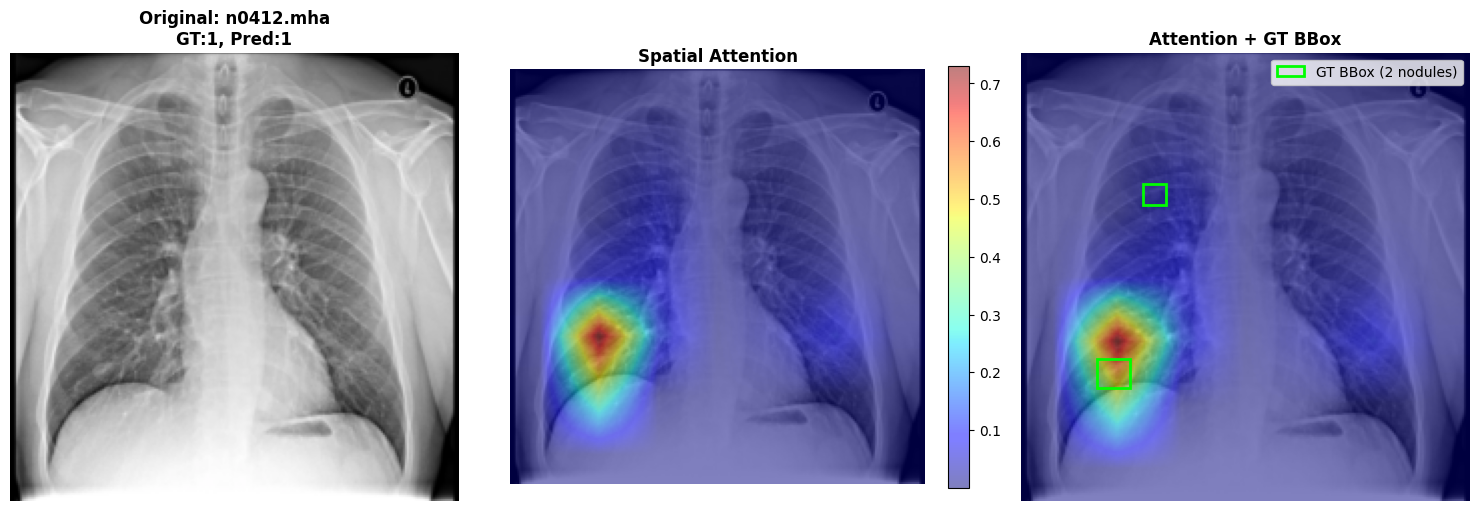


Patient: n0456.mha
  Added bbox: pixel=[535, 664, 109, 103] -> norm=[0.522, 0.648, 0.106, 0.101]
  Found 1 nodule(s)


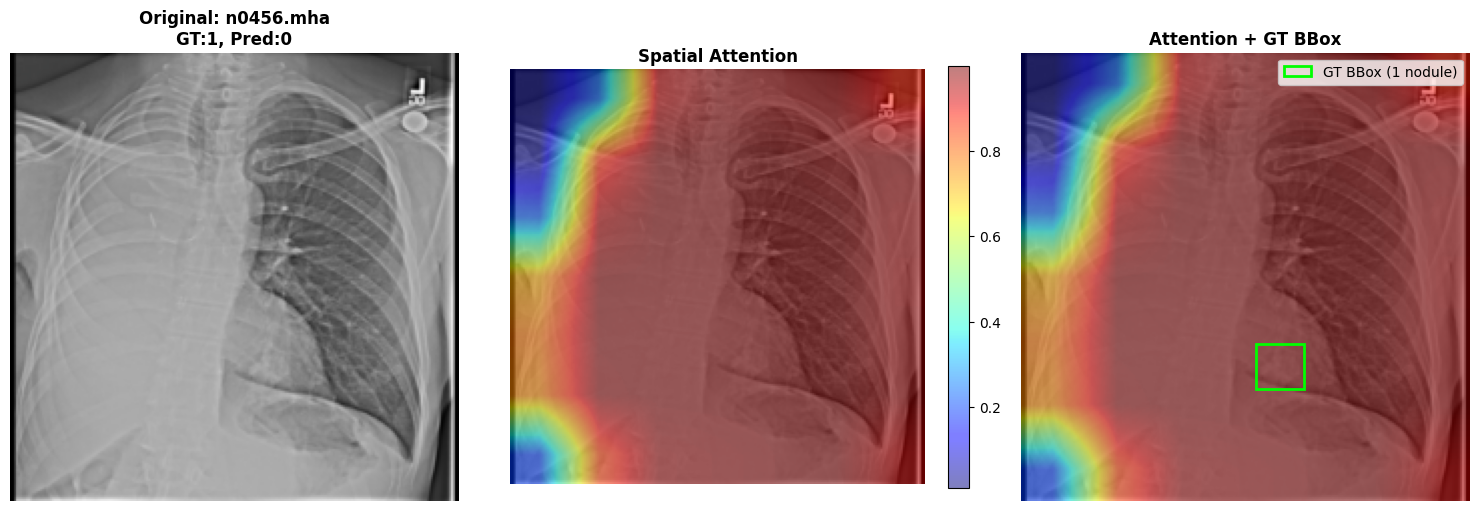


Patient: n0157.mha
  Added bbox: pixel=[689, 554, 62, 73] -> norm=[0.673, 0.541, 0.061, 0.071]
  Added bbox: pixel=[775, 686, 72, 77] -> norm=[0.757, 0.670, 0.070, 0.075]
  Added bbox: pixel=[781, 410, 41, 31] -> norm=[0.763, 0.400, 0.040, 0.030]
  Found 3 nodule(s)


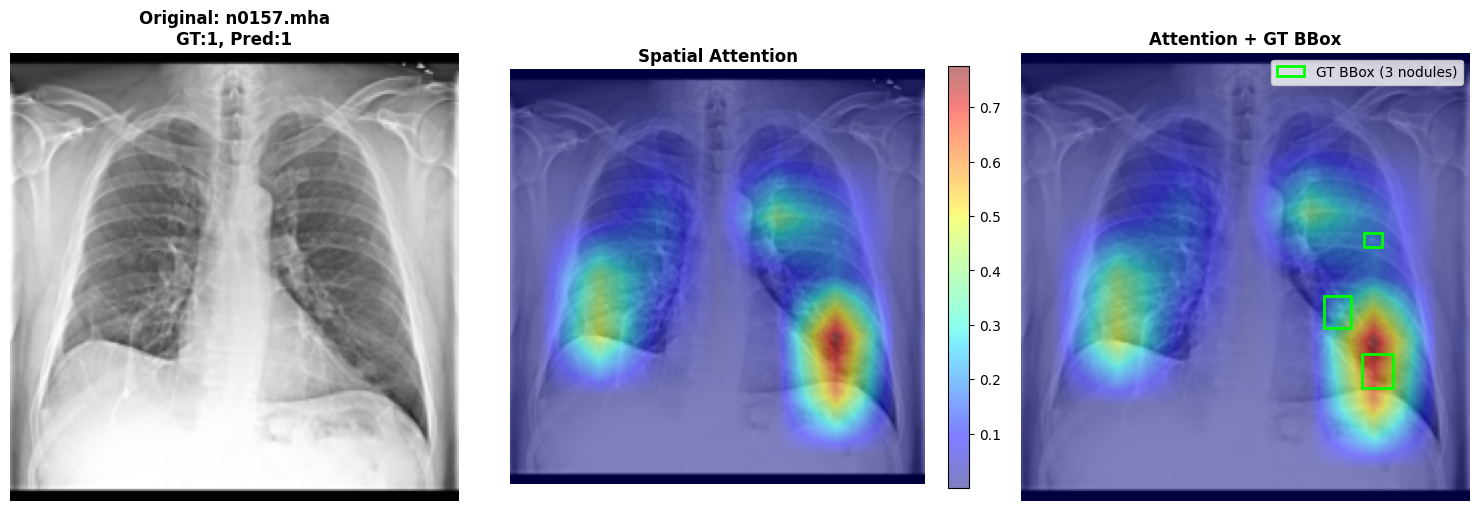


Patient: n0387.mha
  Added bbox: pixel=[818, 601, 37, 40] -> norm=[0.799, 0.587, 0.036, 0.039]
  Added bbox: pixel=[789, 321, 37, 40] -> norm=[0.771, 0.313, 0.036, 0.039]
  Found 2 nodule(s)


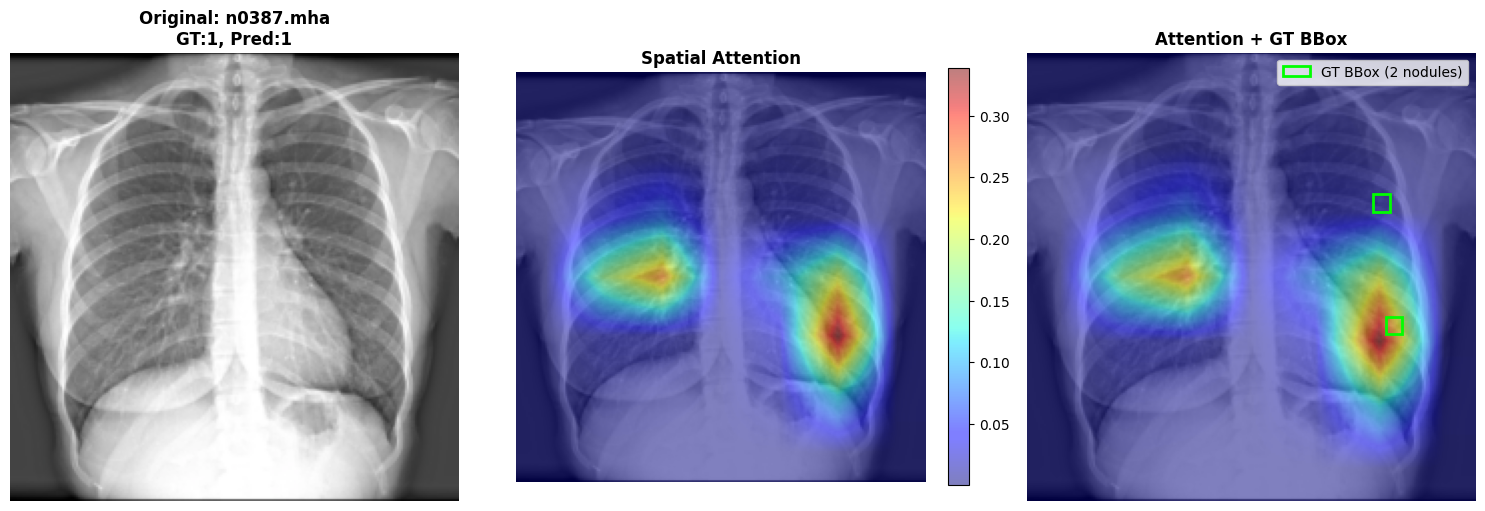


Patient: n0536.mha
  Added bbox: pixel=[166, 569, 78, 83] -> norm=[0.162, 0.556, 0.076, 0.081]
  Found 1 nodule(s)


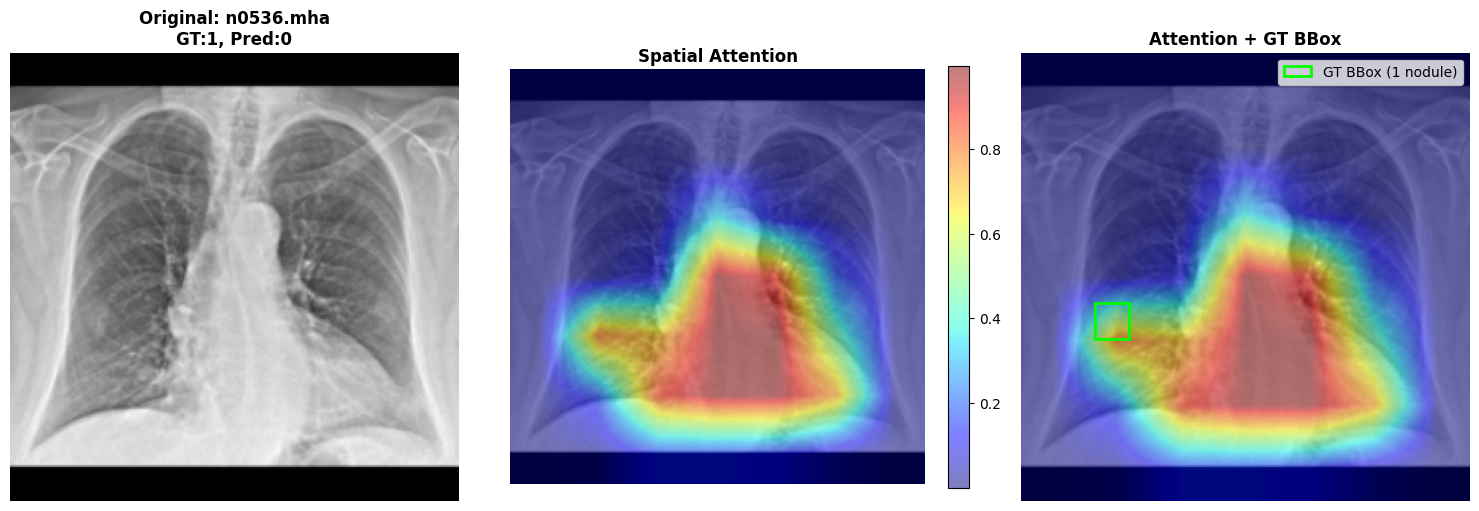


Patient: n0909.mha
  Added bbox: pixel=[279, 378, 49, 46] -> norm=[0.272, 0.369, 0.048, 0.045]
  Added bbox: pixel=[821, 552, 44, 46] -> norm=[0.802, 0.539, 0.043, 0.045]
  Added bbox: pixel=[806, 617, 42, 44] -> norm=[0.787, 0.603, 0.041, 0.043]
  Found 3 nodule(s)


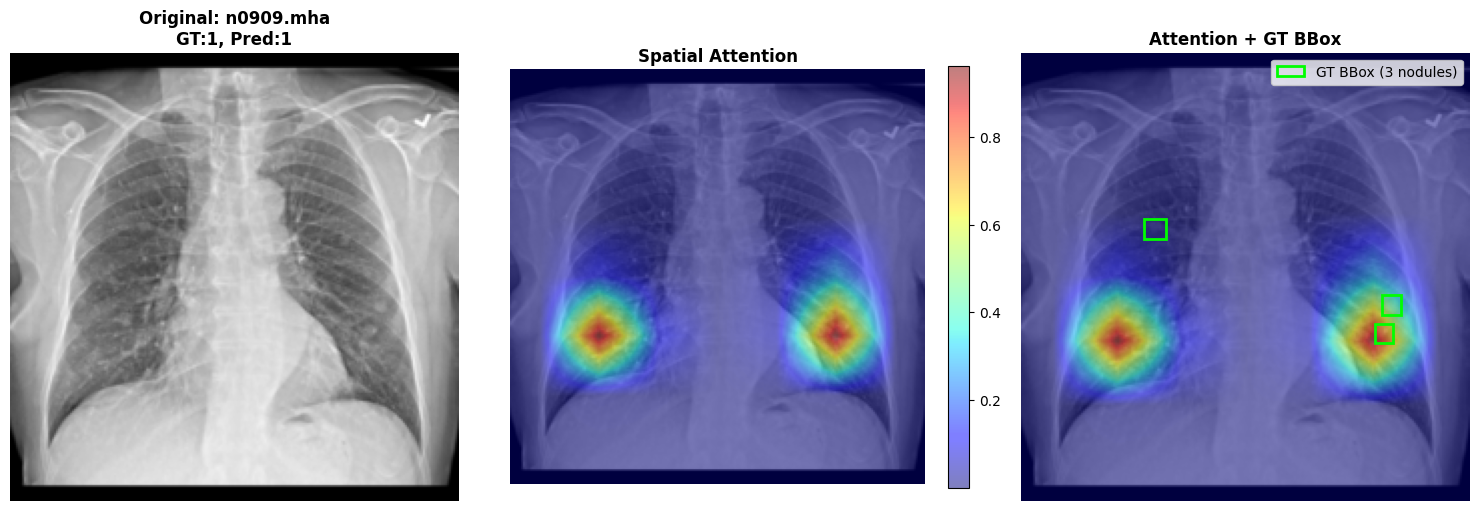


Patient: n0715.mha
  Added bbox: pixel=[213, 691, 64, 76] -> norm=[0.208, 0.675, 0.062, 0.074]
  Found 1 nodule(s)


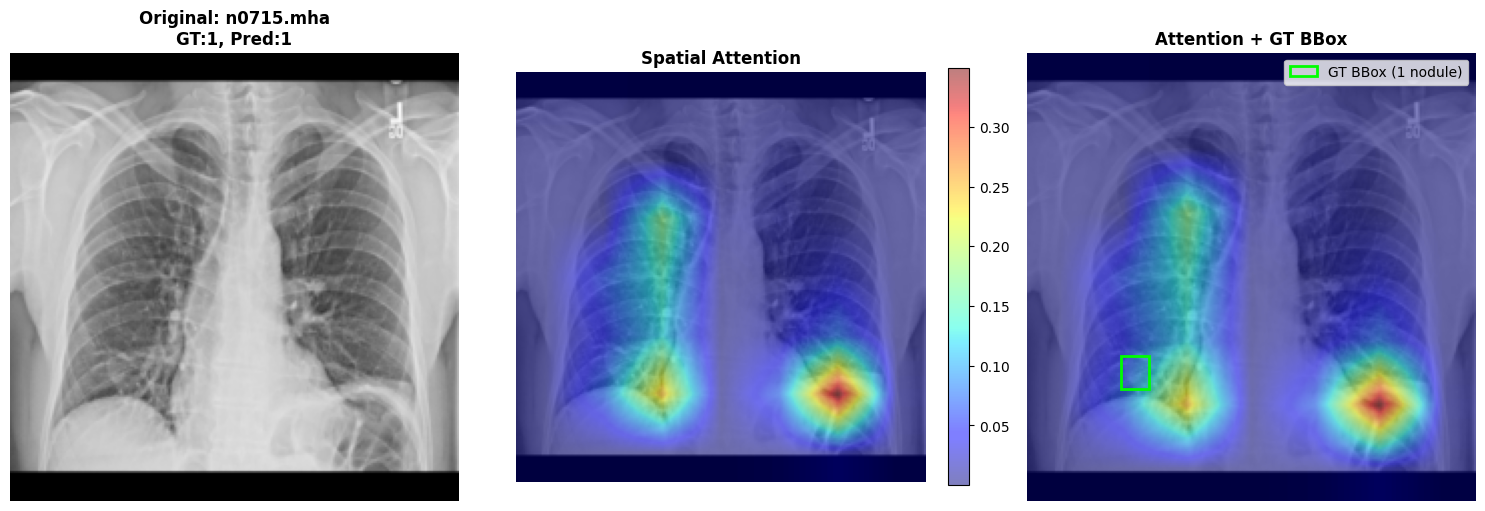


Patient: n0924.mha
  Added bbox: pixel=[752, 576, 31, 40] -> norm=[0.734, 0.562, 0.030, 0.039]
  Found 1 nodule(s)


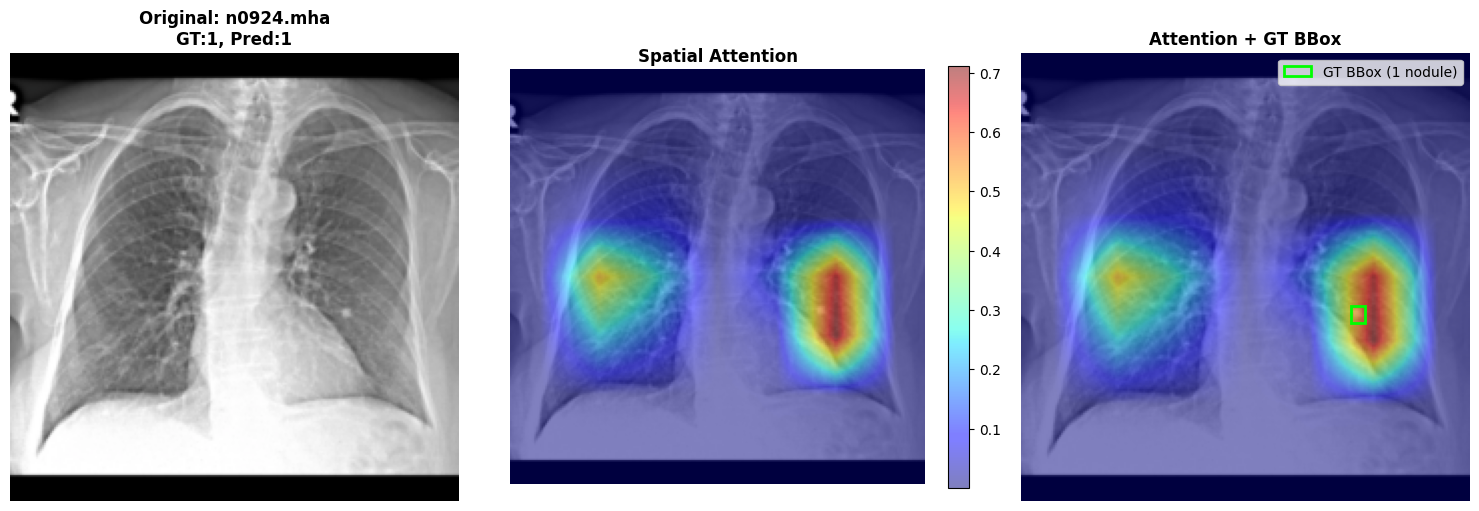


Displayed attention visualizations for 8 unique positive patients
Each visualization shows ALL nodules for that patient

Visualization Complete!


In [ ]:
# ============================================================================
# LOAD BEST MODEL AND VISUALIZE POSITIVE SAMPLES (NODULES) WITH MULTIPLE BBOXES
# ============================================================================

print("\n" + "=" * 80)
print("Loading best model for visualization...")
print("=" * 80)

base_model = timm.create_model('resnet50', pretrained=False, num_classes=2)
model = WSODModelWithAttention(
    base_model,
    num_classes=2,
    freeze_backbone=False,
    num_heads=2,       # ← must match training config
    dropout=0.1        # ← must match training config
).to(device)

# Load the best model checkpoint
best_model_path = './best_wsod_resvit.pth'
checkpoint = torch.load(best_model_path, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

print(f"✓ Loaded best model from epoch {checkpoint.get('epoch', 'unknown')+1}")
print(f"  Val F1:  {checkpoint.get('val_f1',  'unknown'):.4f}")
print(f"  Val AUC: {checkpoint.get('val_auc', 'unknown'):.4f}")
print(f"  Val Acc: {checkpoint.get('val_acc', 'unknown'):.2f}%")

# ============================================================================
# VISUALIZE POSITIVE SAMPLES — everything below is unchanged
# ============================================================================

print("\nFinding positive samples (with nodules) for visualization...")

positive_patients = {}
for i in range(len(test_dataset)):
    _, label, _ = test_dataset[i]
    if label == 1:
        img_name = test_df.iloc[i]['img_name']
        if img_name not in positive_patients:
            positive_patients[img_name] = i

print(f"Found {len(positive_patients)} unique positive patients in test set")

num_vis = min(8, len(positive_patients))
if num_vis > 0:
    selected_patients = np.random.choice(list(positive_patients.keys()), size=num_vis, replace=False)
    print(f"Visualizing {num_vis} random positive patients...")

    for patient_name in selected_patients:
        idx = positive_patients[patient_name]
        img, label, _ = test_dataset[idx]

        print(f"\nPatient: {patient_name}")

        patient_rows = test_df[test_df['img_name'] == patient_name]
        all_bboxes = []

        if 'img_width' in patient_rows.columns and 'img_height' in patient_rows.columns:
            img_width  = patient_rows.iloc[0]['img_width']
            img_height = patient_rows.iloc[0]['img_height']
        else:
            img_width  = 1024
            img_height = 1024

        for _, row in patient_rows.iterrows():
            if row['label'] == 1:
                x_norm = row['x']      / img_width
                y_norm = row['y']      / img_height
                w_norm = row['width']  / img_width
                h_norm = row['height'] / img_height

                bbox_tensor = torch.tensor([x_norm, y_norm, w_norm, h_norm], dtype=torch.float32)
                all_bboxes.append(bbox_tensor)
                print(f"  Added bbox: pixel=[{row['x']:.0f}, {row['y']:.0f}, "
                      f"{row['width']:.0f}, {row['height']:.0f}] -> "
                      f"norm=[{x_norm:.3f}, {y_norm:.3f}, {w_norm:.3f}, {h_norm:.3f}]")

        print(f"  Found {len(all_bboxes)} nodule(s)")

        with torch.no_grad():
            output = model(img.unsqueeze(0).to(device))
            pred   = output.argmax(1).item()

        subfig = visualize_attention_with_bbox(model, img, all_bboxes, label, pred, img_name=patient_name)
        plt.show()

    print(f"\n{'='*80}")
    print(f"Displayed attention visualizations for {num_vis} unique positive patients")
    print(f"Each visualization shows ALL nodules for that patient")
    print(f"{'='*80}")
else:
    print("No positive samples found in test set")

print("\n" + "=" * 80)
print("Visualization Complete!")
print("=" * 80)